In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# ATTCDCNet + DenseNet121  
Clasificación multiclase de neumonía a partir de radiografías de tórax
---


## 1. Importaciones y configuración
```
IMG_SIZE    = (224, 224)   # resolución de entrada
BATCH_SIZE  = 16           # muestras por lote
NUM_CLASSES = 3            # NORMAL / VIRAL / BACTERIAL
train_dir   = "/workspace/data/V2/train" (cambiar por ruta en drive)
val_dir     = "/workspace/data/V2/val"   (cambiar por ruta en drive)
```
--- 
### 2. Configuración de entrenamiento  

| Parámetro        | Valor                                                                                           |
|------------------|-------------------------------------------------------------------------------------------------|
| **Optimizador**  | `Adam`, **lr = 1 × 10‑4**                                                                       |
| **Pérdida**      | `focal_loss(γ = 2, α = 0.25)`                                                                   |
| **Épocas máx.**  | 30                                                                                              |
| **Tamaño de lote** | 16                                                                                            |
| **Callbacks**    | `EarlyStopping(patience=5)` • `ReduceLROnPlateau(patience=3)` • `ModelCheckpoint(best_val_acc)` |
| **Extra conv.**  | `DepthwiseConv2D 3×3` → `Conv2D 1×1` → `BatchNorm`                                              |
| **Atención**     | Squeeze‑Excitation (*ratio* = 8)                                                                |
| **Regularización** | `Dropout`: 0.5 (post‑GAP) y 0.3 (FC)                                                          |

---

### 3. Flujo de trabajo
1. **Carga de datos** — `image_dataset_from_directory` (224 × 224, `label_mode='categorical'`, mezcla con `seed=42`).  
2. **Inicialización** — capas de *DenseNet121* congeladas al inicio; fine‑tuning progresivo opcional.  
3. **Entrenamiento** — detención temprana al estancarse la precisión de validación; el *LR* disminuye × 0.2 tras 3 épocas sin mejora.

---

### 4. Métricas obtenidas  

#### Validación (16 imágenes)  
- **Accuracy** ≈ **0.56**  
- **F1 macro** ≈ **0.53**

| Clase                | Precisión | Recall | F1‑score |
|----------------------|-----------|--------|----------|
| NORMAL               | 0.88      | 0.88   | 0.88     |
| PNEUMONIA‑BACTERIAL  | 0.29      | 0.50   | 0.36     |
| PNEUMONIA‑VIRAL      | 0.00      | 0.00   | 0.00     |

#### Prueba (624 imágenes)  
- **Accuracy** ≈ **0.47**  
- **F1 macro** ≈ **0.40**

| Clase                | Precisión | Recall | F1‑score |
|----------------------|-----------|--------|----------|
| NORMAL               | 0.86      | 0.32   | 0.47     |
| PNEUMONIA‑BACTERIAL  | 0.11      | 0.09   | 0.10     |
| PNEUMONIA‑VIRAL      | 0.50      | 0.86   | 0.63     |

> **Nota:** El modelo confunde con frecuencia `NORMAL` y `VIRAL`; la categoría `BACTERIAL` presenta la tasa de aciertos más baja.

---

### 5. Observaciones
- Alta sensibilidad para la clase **VIRAL**, pero menor precisión posible sobre‑ajuste o desbalance.  

In [3]:
# ATTCDCNet + DenseNet121 para Clasificación Multiclase de Neumonía

# ============================================
# 1. IMPORTACIONES Y CONFIGURACIÓN GENERAL
# ============================================
import tensorflow as tf
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.layers import GlobalAveragePooling2D, Dropout, Dense, BatchNormalization, DepthwiseConv2D, Conv2D, Multiply, Reshape
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuraciones generales
IMG_SIZE = (224, 224)
BATCH_SIZE = 16
NUM_CLASSES = 3
train_dir = "/workspace/data/V2/train"
val_dir   = "/workspace/data/V2/val"
TRAIN_DIR = "/workspace/data/V2/train"
VAL_DIR   = "/workspace/data/V2/val"

# ============================================
# 2. FUNCIÓN DE FOCAL LOSS PERSONALIZADA
# ============================================
def focal_loss(gamma=2., alpha=0.25):
    def focal_loss_fixed(y_true, y_pred):
        epsilon = tf.keras.backend.epsilon()
        y_pred = tf.clip_by_value(y_pred, epsilon, 1. - epsilon)
        cross_entropy = -y_true * tf.math.log(y_pred)
        weight = alpha * tf.math.pow(1 - y_pred, gamma)
        loss = weight * cross_entropy
        return tf.reduce_mean(tf.reduce_sum(loss, axis=1))
    return focal_loss_fixed

# ============================================
# 3. BLOQUE DE ATENCIÓN (Squeeze-Excitation)
# ============================================
def attention_block(x, ratio=8):
    filters = x.shape[-1]
    se = GlobalAveragePooling2D()(x)
    se = Dense(filters // ratio, activation='relu')(se)
    se = Dense(filters, activation='sigmoid')(se)
    se = Reshape((1, 1, filters))(se)
    return Multiply()([x, se])

# ============================================
# 4. CONSTRUCCIÓN DEL MODELO ATTCDCNet
# ============================================
def build_attcdcnet(input_shape=(224, 224, 3), num_classes=3):
    base = DenseNet121(include_top=False, weights='imagenet', input_shape=input_shape)
    x = base.output

    # Bloque convolucional eficiente
    x = DepthwiseConv2D(kernel_size=3, padding='same', activation='relu')(x)
    x = Conv2D(256, kernel_size=1, activation='relu')(x)
    x = BatchNormalization()(x)

    # Atención
    x = attention_block(x)

    # Clasificador final
    x = GlobalAveragePooling2D()(x)
    x = Dropout(0.5)(x)
    x = Dense(128, activation='relu')(x)
    x = Dropout(0.3)(x)
    out = Dense(num_classes, activation='softmax')(x)

    model = Model(inputs=base.input, outputs=out)
    return model, base



In [5]:
# ============================================
# 5. CARGA DE DATOS
# ============================================
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    label_mode='categorical',
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    val_dir,
    label_mode='categorical',
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

Found 5397 files belonging to 3 classes.


2025-07-11 22:33:59.021595: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:982] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2025-07-11 22:33:59.050123: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:982] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2025-07-11 22:33:59.050577: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:982] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2025-07-11 22:33:59.053848: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:982] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2025-07-11 22:33:59.054131: I tensorflow/compile

Found 16 files belonging to 3 classes.


In [6]:
# ============================================
# 6. CALLBACKS PARA ENTRENAMIENTO
# ============================================
callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, verbose=1),
    ModelCheckpoint("best_attcdcnet_model.h5", save_best_only=True, verbose=1)
]

# ============================================
# 7. ENTRENAMIENTO DEL MODELO
# ============================================
model, base_model = build_attcdcnet(input_shape=(224, 224, 3), num_classes=NUM_CLASSES)
base_model.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=focal_loss(gamma=2.0, alpha=0.25),
    metrics=['accuracy']
)

# Entrenar solo la cabeza
history1 = model.fit(train_ds, validation_data=val_ds, epochs=10, callbacks=callbacks)

# Fine-tuning parcial
for layer in model.layers:
    layer.trainable = True
for layer in model.layers[:300]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss=focal_loss(gamma=2.0, alpha=0.25),
    metrics=['accuracy']
)

history2 = model.fit(train_ds, validation_data=val_ds, epochs=10, callbacks=callbacks)

Epoch 1/10


2025-07-11 22:34:07.642562: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_4' with dtype int32 and shape [5397]
	 [[{{node Placeholder/_4}}]]
2025-07-11 22:34:07.642803: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_0' with dtype string and shape [5397]
	 [[{{node Placeholder/_0}}]]
2025-07-11 22:34:11.279447: I tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:424] Loaded cuDNN version 8600
2025-07-11 22:35:48.293355: I tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:637] TensorFloat-32 will be used for the matrix multiplication. This will only be logged once.
2025-07-11 2

338/338 [==============================] - ETA: 0s - loss: 0.1017 - accuracy: 0.5170

2025-07-11 22:36:09.173723: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_4' with dtype int32 and shape [16]
	 [[{{node Placeholder/_4}}]]
2025-07-11 22:36:09.173951: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_4' with dtype int32 and shape [16]
	 [[{{node Placeholder/_4}}]]



Epoch 1: val_loss improved from inf to 0.11551, saving model to best_attcdcnet_model.h5
338/338 [==============================] - 124s 64ms/step - loss: 0.1017 - accuracy: 0.5170 - val_loss: 0.1155 - val_accuracy: 0.5625 - lr: 1.0000e-04
Epoch 2/10
337/338 [============================>.] - ETA: 0s - loss: 0.0788 - accuracy: 0.5760
Epoch 2: val_loss improved from 0.11551 to 0.09504, saving model to best_attcdcnet_model.h5
338/338 [==============================] - 16s 46ms/step - loss: 0.0788 - accuracy: 0.5757 - val_loss: 0.0950 - val_accuracy: 0.5625 - lr: 1.0000e-04
Epoch 3/10
338/338 [==============================] - ETA: 0s - loss: 0.0701 - accuracy: 0.6068
Epoch 3: val_loss improved from 0.09504 to 0.08773, saving model to best_attcdcnet_model.h5
338/338 [==============================] - 16s 48ms/step - loss: 0.0701 - accuracy: 0.6068 - val_loss: 0.0877 - val_accuracy: 0.4375 - lr: 1.0000e-04
Epoch 4/10
337/338 [============================>.] - ETA: 0s - loss: 0.0650 - accur

1/1 [==============================] - 1s 920ms/step

Accuracy: 0.5625
F1 Score: 0.5284090909090909

Reporte de Clasificación:
                      precision    recall  f1-score   support

             NORMAL       0.88      0.88      0.88         8
PNEUMONIA-BACTERIAL       0.29      0.50      0.36         4
    PNEUMONIA-VIRAL       0.00      0.00      0.00         4

           accuracy                           0.56        16
          macro avg       0.39      0.46      0.41        16
       weighted avg       0.51      0.56      0.53        16



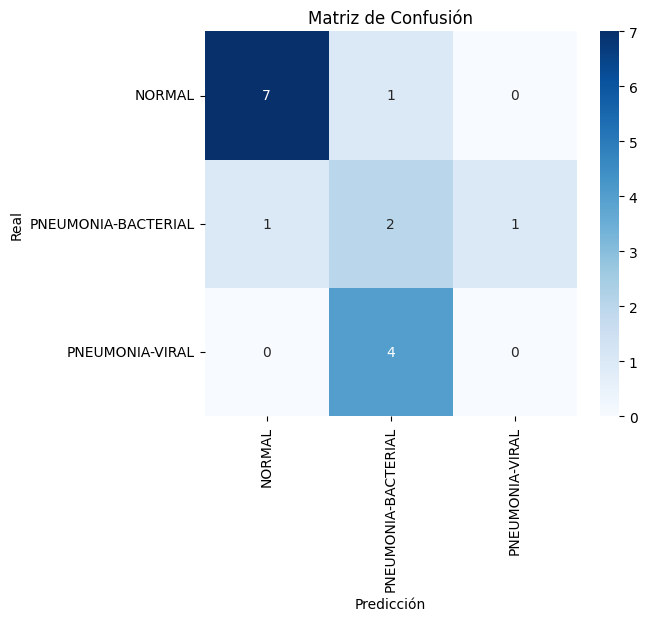

In [7]:
# ============================================
# 8. EVALUACIÓN FINAL DEL MODELO
# ============================================
y_probs = model.predict(val_ds)
y_pred = np.argmax(y_probs, axis=1)
y_true = np.concatenate([np.argmax(label.numpy(), axis=1) for _, label in val_ds])
class_names = ['NORMAL', 'PNEUMONIA-BACTERIAL', 'PNEUMONIA-VIRAL']

acc = accuracy_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred, average='weighted')
report = classification_report(y_true, y_pred, target_names=class_names)
cm = confusion_matrix(y_true, y_pred)

print("\nAccuracy:", acc)
print("F1 Score:", f1)
print("\nReporte de Clasificación:\n", report)

# Matriz de Confusión Visual
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de Confusión")
plt.show()

In [11]:
#!/usr/bin/env python3
# coding: utf-8

"""
AttCDCNet Simplificado sobre DenseNet121 Pretrained
- DenseNet121 imagenet (sin top)
- SE-block + depthwise separable conv sobre la salida final del extractor
- Focal Loss
- Data augmentation
- Callbacks (EarlyStopping, ReduceLROnPlateau, ModelCheckpoint)
"""

import os
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.metrics import classification_report, confusion_matrix

# 1) Configuración
IMG_SIZE    = (224, 224)
BATCH_SIZE  = 16
NUM_CLASSES = 3
TRAIN_DIR   = "/workspace/data/V2/train"
VAL_DIR     = "/workspace/data/V2/val"
TEST_DIR    = "/workspace/data/V2/test"

# 2) Pérdida focal
def focal_loss(alpha=0.25, gamma=2.0):
    def loss_fn(y_true, y_pred):
        eps = tf.keras.backend.epsilon()
        y_pred = tf.clip_by_value(y_pred, eps, 1.0 - eps)
        ce = -y_true * tf.math.log(y_pred)
        weight = alpha * tf.math.pow(1 - y_pred, gamma)
        return tf.reduce_mean(tf.reduce_sum(weight * ce, axis=-1))
    return loss_fn

# 3) SE-block
def se_block(x, ratio=8):
    filters = x.shape[-1]
    se = layers.GlobalAveragePooling2D()(x)
    se = layers.Dense(filters // ratio, activation='relu')(se)
    se = layers.Dense(filters, activation='sigmoid')(se)
    se = layers.Reshape((1,1,filters))(se)
    return layers.Multiply()([x, se])

# 4) Construcción del modelo
def build_attcdcnet(input_shape=(224,224,3), num_classes=3):
    # Backbone pretrained
    base = DenseNet121(include_top=False,
                       weights='imagenet',
                       input_shape=input_shape)
    x = base.output

    # SE + depthwise separable conv
    x = se_block(x, ratio=8)
    x = layers.DepthwiseConv2D(3, padding='same', activation='relu')(x)
    x = layers.Conv2D(x.shape[-1], 1, activation='relu')(x)
    x = layers.BatchNormalization()(x)

    # Clasificador
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = Model(inputs=base.input, outputs=outputs, name="AttCDCNet_Simplified")
    return model

# 5) Data pipeline
def make_datasets():
    train_ds = tf.keras.preprocessing.image_dataset_from_directory(
        TRAIN_DIR, image_size=IMG_SIZE, batch_size=BATCH_SIZE
    )
    val_ds = tf.keras.preprocessing.image_dataset_from_directory(
        VAL_DIR, image_size=IMG_SIZE, batch_size=BATCH_SIZE
    )
    test_raw = tf.keras.preprocessing.image_dataset_from_directory(
        TEST_DIR, image_size=IMG_SIZE, batch_size=BATCH_SIZE, shuffle=False
    )

    aug = tf.keras.Sequential([
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.1),
        layers.RandomZoom(0.1),
    ])

    def prep(ds, training=False):
        def f(x, y):
            x = tf.cast(x, tf.float32) / 255.0
            if training: x = aug(x)
            y = tf.one_hot(y, NUM_CLASSES)
            return x, y
        return ds.map(f).prefetch(tf.data.AUTOTUNE)

    return prep(train_ds, True), prep(val_ds), test_raw, prep(test_raw)

# 6) Ensamblar y compilar
model = build_attcdcnet((*IMG_SIZE, 3), NUM_CLASSES)
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss=focal_loss(alpha=0.25, gamma=2.0),
    metrics=["accuracy"]
)

# 7) Callbacks
callbacks = [
    EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.1, patience=4),
    ModelCheckpoint("attcdcnet_best.h5", monitor="val_accuracy", save_best_only=True)
]

# 8) Entrenamiento
train_ds, val_ds, test_raw, test_ds = make_datasets()
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,
    callbacks=callbacks
)

# 9) Evaluación final
model.load_weights("attcdcnet_best.h5")
val_loss, val_acc = model.evaluate(val_ds)
print(f"\nValidation Accuracy: {val_acc:.4f}\n")

# Reporte en test
y_true = np.concatenate([y for _, y in test_raw], axis=0)
y_pred = np.argmax(model.predict(test_ds), axis=1)
print("Classification Report:\n",
      classification_report(y_true, y_pred, target_names=['NORMAL', 'PNEUMONIA-BACTERIAL', 'PNEUMONIA-VIRAL']))
print("Confusion Matrix:\n", confusion_matrix(y_true, y_pred))


Found 5397 files belonging to 3 classes.
Found 16 files belonging to 3 classes.
Found 624 files belonging to 3 classes.
Epoch 1/50


2025-07-11 22:57:18.495725: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_18' with dtype resource
	 [[{{node Placeholder/_18}}]]
2025-07-11 22:57:18.496000: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_0' with dtype string and shape [5397]
	 [[{{node Placeholder/_0}}]]


338/338 [==============================] - ETA: 0s - loss: 0.0915 - accuracy: 0.5251

2025-07-11 22:58:49.640185: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_4' with dtype int32 and shape [16]
	 [[{{node Placeholder/_4}}]]
2025-07-11 22:58:49.640399: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_4' with dtype int32 and shape [16]
	 [[{{node Placeholder/_4}}]]


338/338 [==============================] - 93s 171ms/step - loss: 0.0915 - accuracy: 0.5251 - val_loss: 0.1229 - val_accuracy: 0.2500 - lr: 0.0010
Epoch 2/50
338/338 [==============================] - 57s 168ms/step - loss: 0.0764 - accuracy: 0.5792 - val_loss: 0.3146 - val_accuracy: 0.2500 - lr: 0.0010
Epoch 3/50
338/338 [==============================] - 58s 171ms/step - loss: 0.0752 - accuracy: 0.5623 - val_loss: 0.3051 - val_accuracy: 0.3125 - lr: 0.0010
Epoch 4/50
338/338 [==============================] - 58s 170ms/step - loss: 0.0731 - accuracy: 0.5801 - val_loss: 0.9567 - val_accuracy: 0.5000 - lr: 0.0010
Epoch 5/50
338/338 [==============================] - 57s 170ms/step - loss: 0.0690 - accuracy: 0.5901 - val_loss: 0.0934 - val_accuracy: 0.5625 - lr: 0.0010
Epoch 6/50
338/338 [==============================] - 56s 164ms/step - loss: 0.0673 - accuracy: 0.5877 - val_loss: 1.2700 - val_accuracy: 0.2500 - lr: 0.0010
Epoch 7/50
338/338 [==============================] - 56s 164ms

2025-07-11 23:12:56.913086: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_4' with dtype int32 and shape [624]
	 [[{{node Placeholder/_4}}]]
2025-07-11 23:12:56.913341: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_4' with dtype int32 and shape [624]
	 [[{{node Placeholder/_4}}]]
2025-07-11 23:12:56.973962: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_4' with dtype int32 and shape [624]
	 [[

39/39 [==============================] - 3s 42ms/step
Classification Report:
                      precision    recall  f1-score   support

             NORMAL       0.86      0.32      0.47       234
PNEUMONIA-BACTERIAL       0.11      0.09      0.10       156
    PNEUMONIA-VIRAL       0.50      0.86      0.63       234

           accuracy                           0.47       624
          macro avg       0.49      0.43      0.40       624
       weighted avg       0.54      0.47      0.44       624

Confusion Matrix:
 [[ 76  91  67]
 [  6  14 136]
 [  6  26 202]]
